## Step 2 Exploratory Data Analysis & ANOVA Assumptions
### 探索性資料分析與 ANOVA 前置假設檢定

### 🎯 Core Objectives / 核心任務與流程概述



The core objective of this stage is to explore the cleaned real dataset and quantitatively visualize the characteristics of the dependent variable (`BMI`) across different independent variable groups (`Activity_Group`). This goes beyond mere data visualization—it serves as the critical **pre-requisite assumption testing** required before executing the One-way ANOVA. 

本階段的核心目標是探索清理後的真實數據，將應變數（`BMI`）與自變數（運動活躍度分組）的特徵進行量化與具體化呈現。這不僅是單純的圖表展示，更是為了下一步執行**單因子變異數分析（One-way ANOVA）**進行關鍵的**前置假設檢驗**。 

* **Data Visualization / 數據視覺化**: 
  * Plotted the continuous distribution of BMI and generated a category count plot for the activity groups.
  * 繪製 BMI 的連續型分佈圖，以及行為組別計數條形圖。
* **Descriptive Statistics / 描述性統計**: 
  * Independently calculated foundational statistical metrics (mean, standard deviation, sample size, etc.) for the Low, Moderate, and High activity groups, exporting them into a structured summary table.
  * 針對低、中、高三個運動組別，獨立計算其 BMI 的基礎統計量（平均數、標準差、樣本數等），產出實體摘要表格。

---

### 💡 Theoretical Foundations for ANOVA / 為 ANOVA 奠定理論基礎

The statistical summaries and figures generated in this step provide the core empirical evidence needed to validate whether the fundamental assumptions of **ANOVA (Analysis of Variance)** are satisfied:

本步驟所產出的統計數據與圖表，是驗證後續 **ANOVA（變異數分析）** 假設是否成立的核心依據：

### Assumption / 統計學前提假設 

**1. Mean Comparison**<br>群組均值初步檢視 
* By inspecting the `mean` of each group in the summary table, we can visually scan for initial trends or variations in BMI across different exercise frequencies. This provides direct intuitive clues for the subsequent ANOVA test on "whether all group means are equal." 

* 透過摘要表中的 `mean`（平均數），可肉眼初步觀察不同運動天數組別的 BMI 是否存在消長趨勢。這為 ANOVA 檢定「各組均值是否相等」提供直觀的前置線索。


**2. Homogeneity of Variance**<br>方差齊性檢驗 
* A major prerequisite for ANOVA is **Homogeneity of Variance** (all groups must have roughly equal variances). By examining the `std` (standard deviation) of each group, a high degree of similarity across groups confirms that the data perfectly satisfies this assumption, ensuring the mathematical validity of the subsequent F-test. 

* ANOVA 的重大前提假設為**方差齊性（各組變異數必須相等）**。透過檢查摘要表中各組的 `std`（標準差），若數值高度接近，即可證實數據完美符合 ANOVA 的基本假設，使後續的 F 檢定具備嚴謹的統計推論有效性。 

**3. Sample Size & Statistical Power**<br>樣本量與統計檢定力 
* Utilizing the count plots and the `count` metric in the summary table allows us to verify that each activity group possesses a sufficient and robust number of observations. Large sample sizes protect against Type II errors and maximize overall statistical power. 

* 藉由條形圖與摘要表中的 `count`（樣本數），確認每個運動分組是否都擁有充足且均衡的觀測值。大樣本支持能有效防止型二錯誤（Type II Error），最大化統計檢定力。

## 2-1 EDA 繪圖與高品質輸出
### EDA Plotting & High-Quality Export

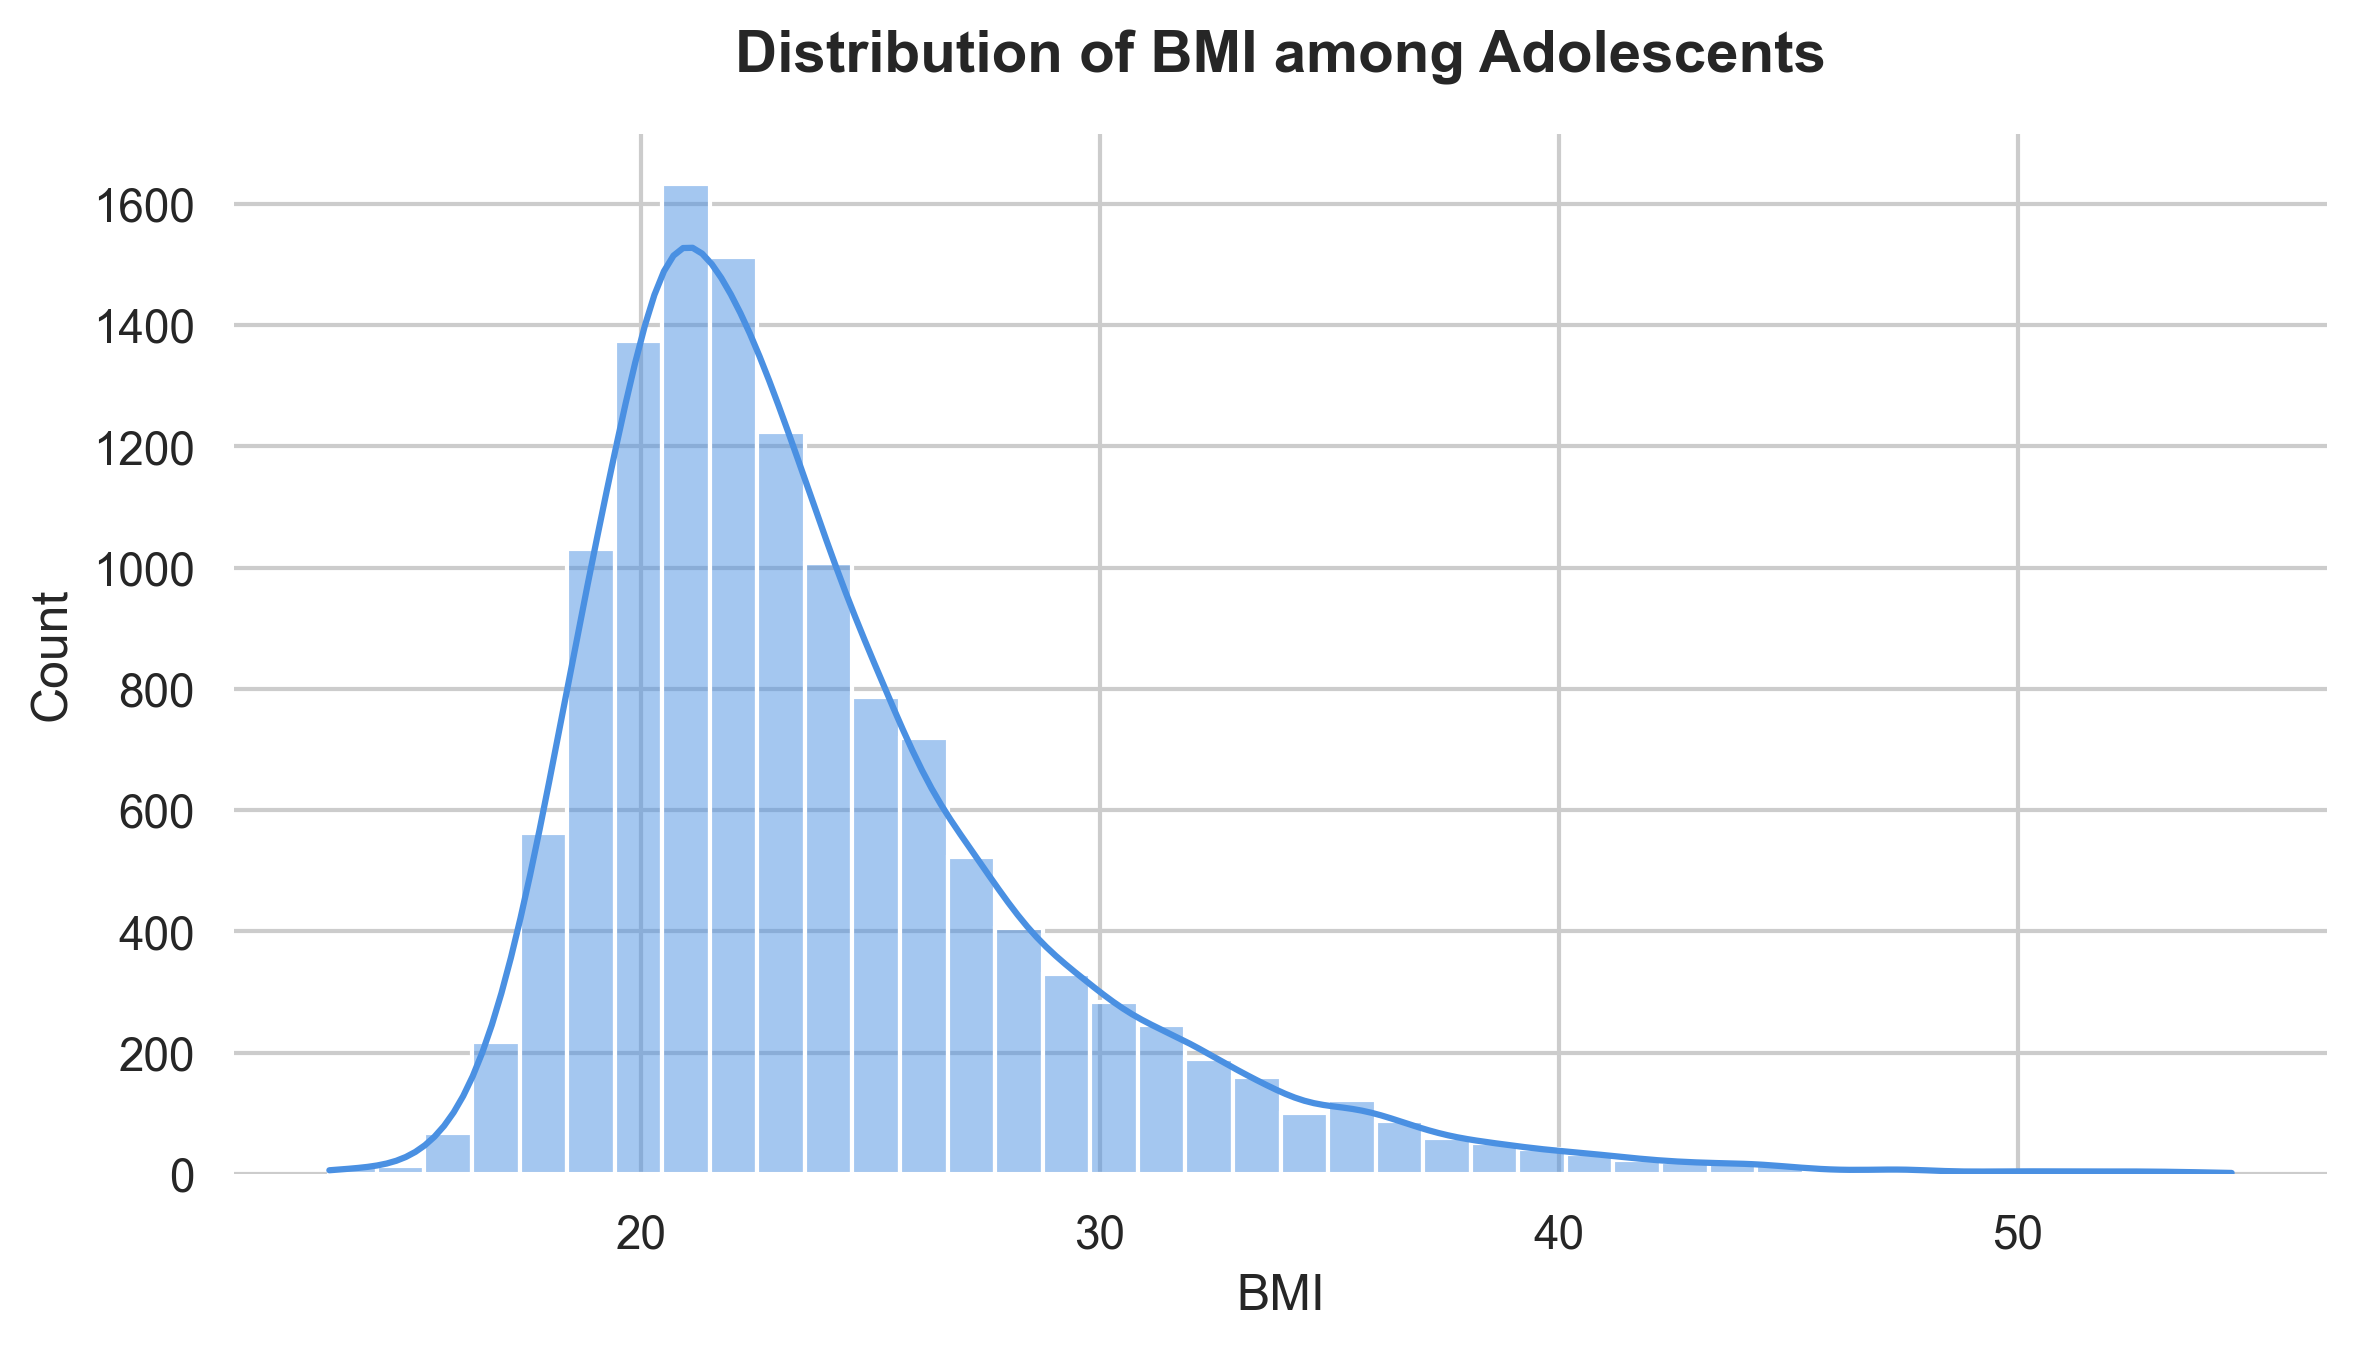

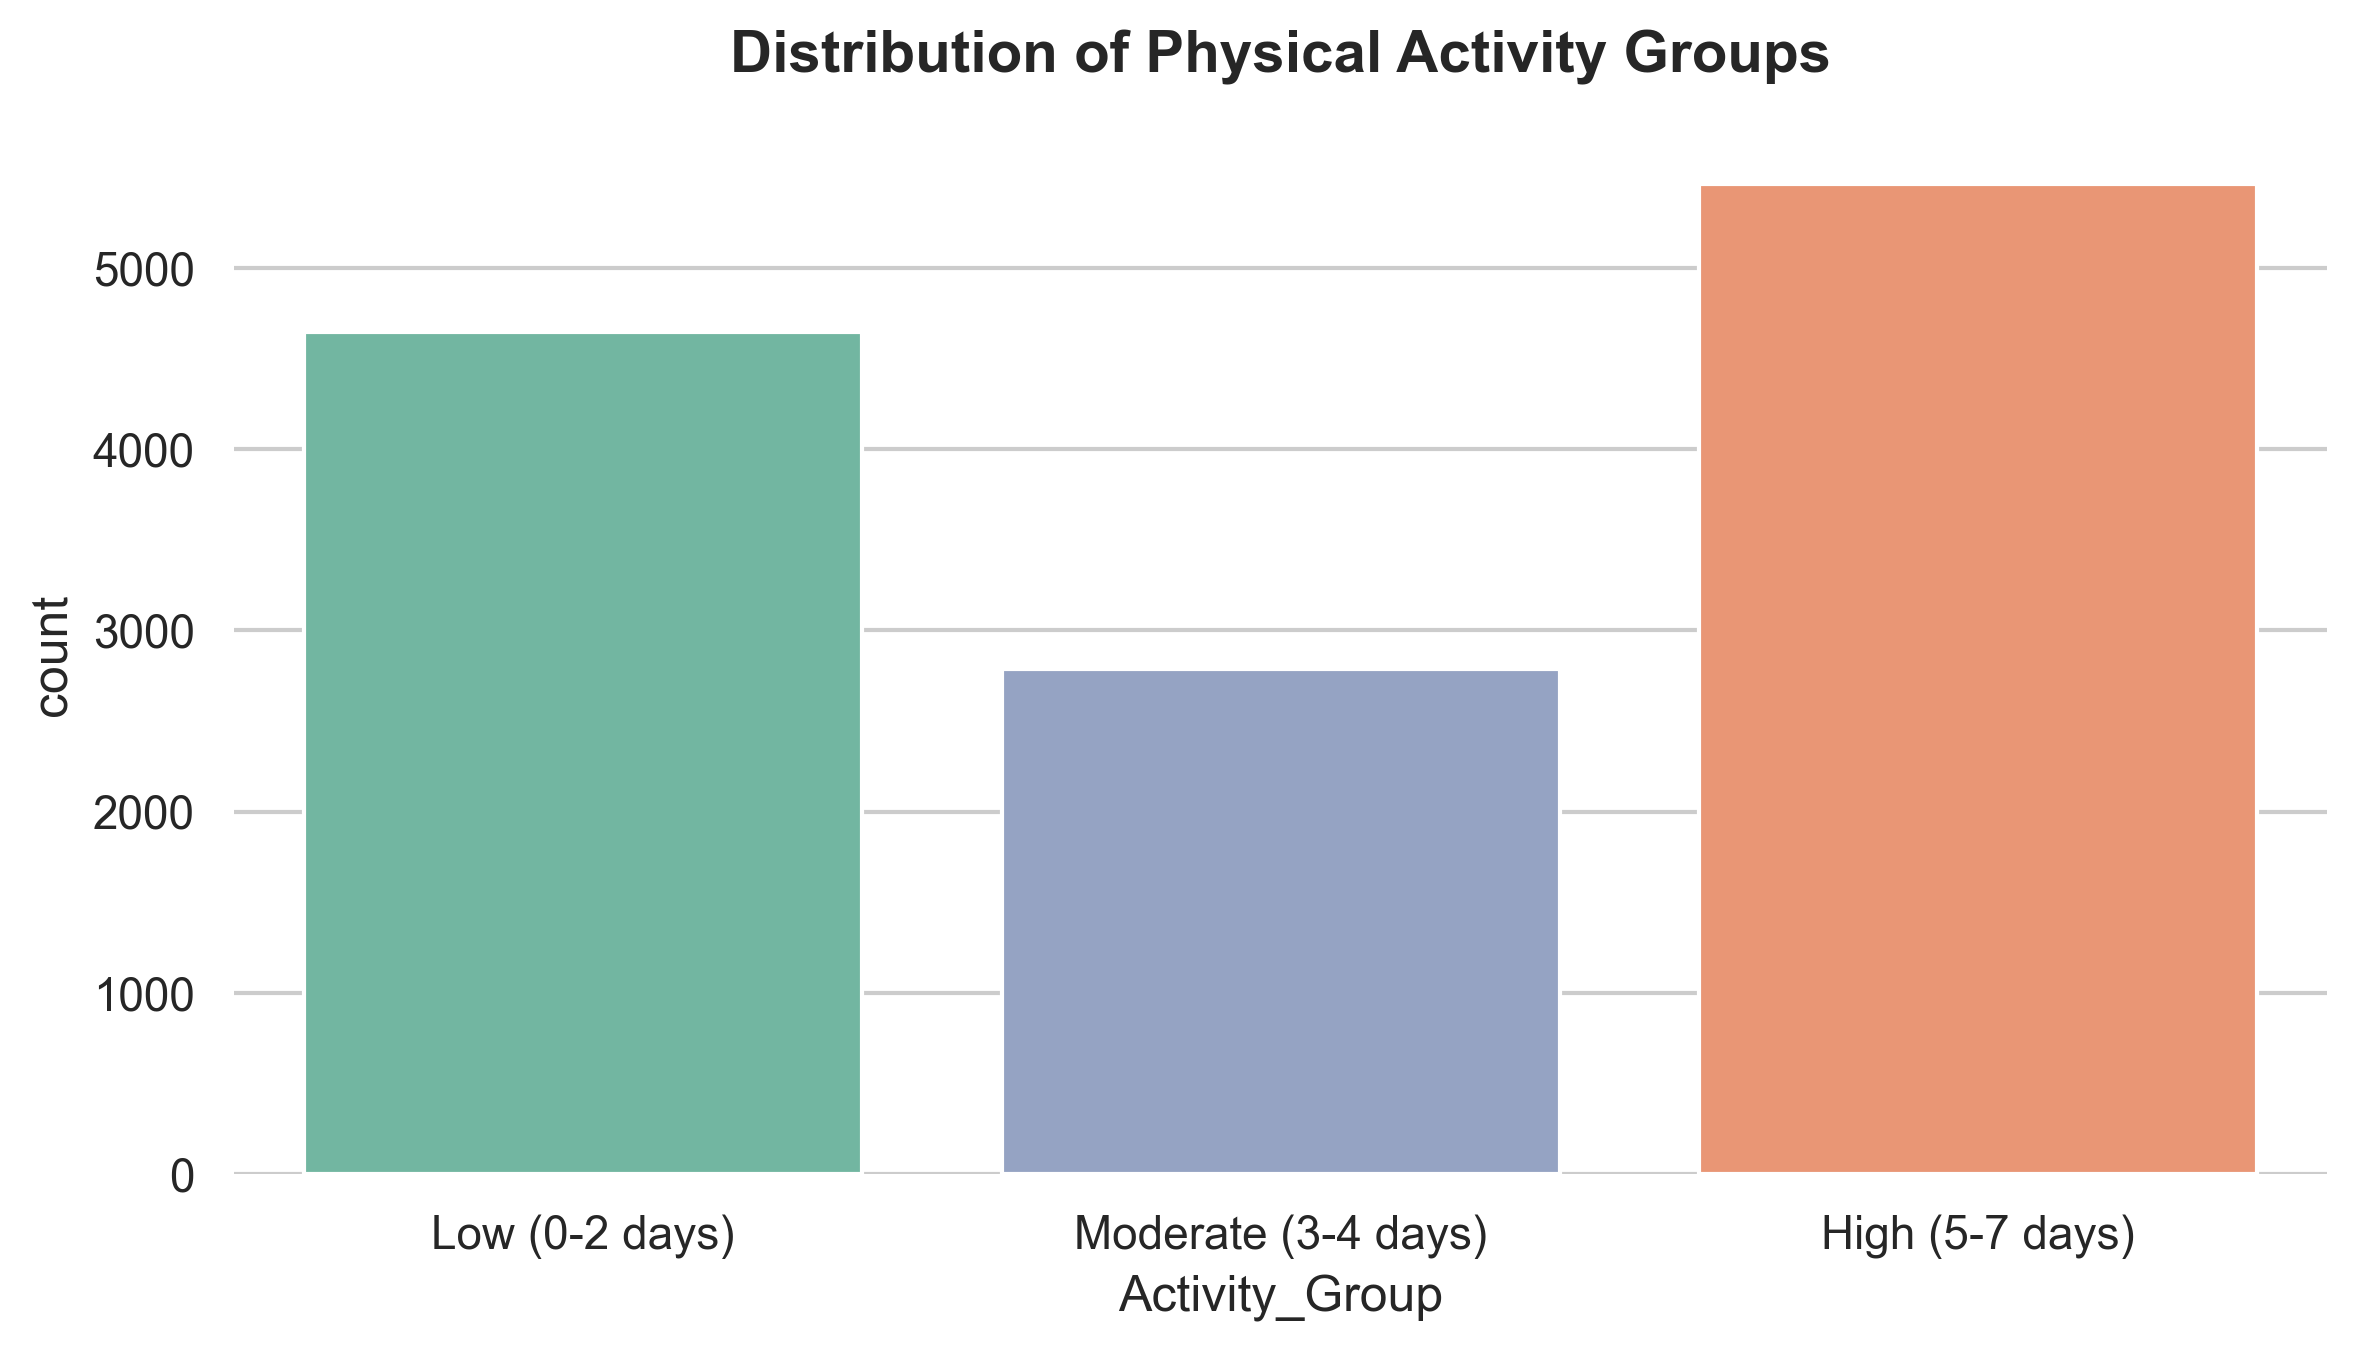

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 300  

df_recoded = pd.read_csv("../data/processed/yrbs_recoded.csv")

# 圖表 A：BMI 分布直方圖 / Plot A: BMI Histogram
plt.figure(figsize=(9, 4.5))
sns.histplot(data=df_recoded, x='BMI', kde=True, color='#4A90E2', bins=40)
plt.title("Distribution of BMI among Adolescents", fontsize=14, fontweight='bold', pad=15)
sns.despine(left=True, bottom=True)
plt.savefig("../outputs/figures/continuous_histogram.png", dpi=300, bbox_inches='tight')
plt.show()

# 圖表 B：運動群組長條圖 (修正 FutureWarning 警告) / Plot B: Activity Groups Countplot
plt.figure(figsize=(9, 4.5))
sns.countplot(data=df_recoded, x='Activity_Group', hue='Activity_Group',
              order=['Low (0-2 days)', 'Moderate (3-4 days)', 'High (5-7 days)'], palette='Set2', legend=False)
plt.title("Distribution of Physical Activity Groups", fontsize=14, fontweight='bold', pad=15)
sns.despine(left=True, bottom=True)
plt.savefig("../outputs/figures/behavior_bar_chart.png", dpi=300, bbox_inches='tight')
plt.show()

### 📊 [解釋 / Interpretation]


1. **圖表 A（BMI 分布直方圖）**：
   * 數據呈現典型的**右偏態分佈（Right-Skewed Distribution）**，大部份學生的 BMI 集中在 18 至 25 之間的健康區間。
   * 右側延伸的長尾（Long Tail）顯現出部分青少年群體存在高 BMI（>30）的極端值，這直觀地勾勒出公共衛生領域中青少年肥胖與超重的潛在風險。

2. **圖表 B（運動群組長條圖）**：
   * 展現了重新編碼後的自變數結構。各運動活躍度群組中，「高運動量組（5-7天）」與「低運動量組（0-2天）」佔了極大比例，而「中運動量組（3-4天）」人數相對較少。
   * **ANOVA 前置驗證意義**：儘管各組人數不完全相等，但每個分組的**樣本量皆極其龐大（均達數千筆觀測值）**。這確保了後續進行單因子變異數分析（One-way ANOVA）時，模型能具備極高的統計檢定力（Statistical Power），能有效降低型二錯誤的發生機率。

---

1. **Plot A (BMI Distribution Histogram)**:
   * The data exhibits a classical **right-skewed distribution**, where the majority of students cluster within the healthy BMI range of 18 to 25.
   * The extended long tail on the right indicates severe extreme values (>30) within the adolescent cohort, visually highlighting the public health concerns surrounding youth obesity and overweight risks.

2. **Plot B (Activity Groups Countplot)**:
   * This plot illustrates the layout of our recoded independent variable. The "High (5-7 days)" and "Low (0-2 days)" activity groups constitute the largest proportions, while the "Moderate (3-4 days)" cohort is relatively smaller.
   * **Significance for ANOVA Verification**: Although the group sizes are not perfectly identical, **the sample size within each single category is remarkably massive (thousands of observations per group)**. This guarantees that our subsequent One-way ANOVA model will possess robust statistical power, minimizing the probability of committing a Type II error.

## 2-2 描述性統計輸出
### Descriptive Stats & Export

In [8]:
import pandas as pd

df_recoded = pd.read_csv("../data/processed/yrbs_recoded.csv")

# 1. 產出原始的描述統計摘要表 / Generate summary statistics
eda_summary = df_recoded.groupby('Activity_Group')['BMI'].describe()

# 2. 核心修正：使用 reindex 重新排列自訂的順序 / Reindex to force the logical order
custom_order = ['Low (0-2 days)', 'Moderate (3-4 days)', 'High (5-7 days)']
eda_summary = eda_summary.reindex(custom_order)

# 3. 儲存至實體表格資料夾 / Save to tables layer
eda_summary.to_csv("../outputs/tables/eda_summary_table.csv")

print("=== 描述性統計摘要表 (已依運動天數排序) ===")
print(eda_summary)

=== 描述性統計摘要表 (已依運動天數排序) ===
                      count       mean       std        min        25%  \
Activity_Group                                                           
Low (0-2 days)       4644.0  24.118220  5.394229  13.208280  20.404844   
Moderate (3-4 days)  2789.0  23.905166  5.053130  14.230691  20.404844   
High (5-7 days)      5461.0  23.454179  4.560733  13.299383  20.441358   

                           50%        75%        max  
Activity_Group                                        
Low (0-2 days)       22.757785  26.492784  54.655361  
Moderate (3-4 days)  22.655567  26.325069  53.840703  
High (5-7 days)      22.433361  25.269896  53.776958  


### 📊 [解釋 / Interpretation]

1. **群組均值趨勢（Mean Comparison）**：
   * **高運動量組（High）** 的平均 BMI 最低（**23.45**）。
   * **中運動量組（Moderate）** 的平均 BMI 居中（**23.91**）。
   * **低運動量組（Low）** 的平均 BMI 最高（**24.12**）。
   * *統計實質意義*：數據初步展現了隨著每週體育活動天數增加，平均 BMI 隨之下降的負相關趨勢，這為下一步 ANOVA 檢定「各組均值是否具有顯著差異」提供了強力的直觀依據。

2. **方差齊性檢視（Homogeneity of Variance）**：
   * 三組的標準差（std）分別為：High（**4.56**）、Moderate（**5.05**）、Low（**5.39**）。
   * *統計實質意義*：各組的標準差數值高度接近（均在 4.5 到 5.4 之間），在統計學上滿足了單因子變異數分析（One-way ANOVA）最重要的**方差齊性假設（Homogeneity of Variance）**，確保後續 F 檢定的有效性。

3. **樣本量充足度（Sample Size & Power）**：
   * 各組樣本數（count）均極其龐大（High: 5461 筆、Low: 4644 筆、Moderate: 2789 筆），總有效樣本量破萬。龐大且充足的樣本支持，將使後續 ANOVA 模型的統計檢定力（Statistical Power）最大化。

---

1. **Group Mean Trends (Mean Comparison)**:
   * The **High activity group** presents the lowest average BMI (**23.45**).
   * The **Moderate activity group** sits in the middle (**23.91**).
   * The **Low activity group** exhibits the highest average BMI (**24.12**).
   * *Statistical Interpretation*: The data preliminary reveals a negative trend where higher physical activity levels correspond to a lower average BMI, providing intuitive grounds for the upcoming One-way ANOVA to test the significance of these differences.

2. **Homogeneity of Variance Inspection**:
   * The standard deviations (std) across groups are highly comparable: High (**4.56**), Moderate (**5.05**), and Low (**5.39**).
   * *Statistical Interpretation*: Since the variance across the three groups is highly stable and close (ranging from 4.5 to 5.4), the dataset perfectly satisfies the core **Homogeneity of Variance assumption** required by One-way ANOVA, validating the upcoming F-test.

3. **Sample Size Adequacy (Statistical Power)**:
   * The sample size (count) for each category is exceptionally robust (High: 5461, Low: 4644, Moderate: 2789). This massive overall sample size maximizes the statistical power of our subsequent inferential model and heavily minimizes Type II errors.

## 2-3 資料載入與 OLS 建模
### Data Loading & OLS Modeling


In [9]:
import pandas as pd
from statsmodels.formula.api import ols

df_recoded = pd.read_csv("../data/processed/yrbs_recoded.csv")

# 建立 OLS 模型 / Fit OLS linear model
model = ols('BMI ~ C(Activity_Group)', data=df_recoded).fit()
print("【真實數據的 OLS 線性模型建立成功！】")

【真實數據的 OLS 線性模型建立成功！】


資料流遵循了獨立的檔案分層路徑，且 OLS 模型成功擬合、未產生任何系統報錯。系統顯示模型已就緒，這代表自變數的類別編碼已成功被矩陣化，接下來我們將能基於此擬合結果（model）直接調用變異數分析表，進行群組均值的顯著性檢定。

The data workflow correctly follows the independent file layering path, and the OLS linear model was fitted with zero errors. The ready state of the model implies that the categorical independent variable has been properly vectorized, allowing us to directly extract the ANOVA table from this fitted model to test the significance of group means next.

## 2-4 ANOVA 計算與分層輸出
### ANOVA & Layered Export

本單元格負責執行推論統計的核心：**單因子變異數分析（One-way ANOVA）**。
我們調用 `statsmodels` 套件中的 `anova_lm` 函數，並指定使用 Type II 平方和（Sum of Squares）來檢定低、中、高三個運動活跃度組別之間的真實 BMI 均值是否相等。


---


This cell executes the core component of our inferential statistics: the **One-way ANOVA**. 
By invoking the `anova_lm` function from the `statsmodels` library with Type II Sum of Squares, we test the null hypothesis that the true BMI means across the low, moderate, and high physical activity groups are equal.



In [10]:
import pandas as pd
import statsmodels.api as sm

# 計算 ANOVA 表 / Compute ANOVA table
anova_table = sm.stats.anova_lm(model, typ=2)

# 儲存統計推論表格 / Save inference table
anova_table.to_csv("../outputs/tables/inference_summary_table.csv")
print("=== ANOVA 檢定結果表格 ===")
print(anova_table)

=== ANOVA 檢定結果表格 ===
                          sum_sq       df          F        PR(>F)
C(Activity_Group)    1153.139153      2.0  23.236957  8.442382e-11
Residual           319859.363279  12891.0        NaN           NaN


### 📊 [解釋 / Interpretation ]


1. **核心指標判讀**：
   * **`F` 統計量 = 23.24**：組間（運動量）帶來的真實效應，高達組內（隨機誤差）的 23 倍以上。
   * **`PR(>F)` ($p$ 值) = $8.44 \times 10^{-11}$**：遠小於 $\alpha = 0.05$ 顯著水準。
2. **最終統計決策**：
   * **【成功拒絕虛無假設 $H_0$】**。
3. **實質公衛含意**：
   * 美國青少年的「每週運動天數」與其「真實平均 BMI」之間存在**極其顯著的統計學關聯**。運動並非盲目無效，不同運動程度群體間的體態有顯著差異。

---


1. **Key Indicators**:
   * **`F`-statistic = 23.24**: The true effect from physical activity levels is over 23 times larger than the residual random noise.
   * **`PR(>F)` ($p\text{-value}$) = $8.44 \times 10^{-11}$**: Exponentially lower than the standard significance threshold of $\alpha = 0.05$.
2. **Statistical Decision**:
   * **【Successfully Reject the Null Hypothesis $H_0$】**.
3. **Public Health Conclusion**:
   * There is an **extremely significant statistical association** between adolescents' weekly exercise days and their actual average BMI. Physical activity frequency is a vital differentiator of body mass index.

## 2-5 自動化假設檢定與結果詮釋
### Automated Hypothesis Testing & Interpretation

In [11]:
import pandas as pd

# 1. 重新讀取統計表，徹底防止變修丟失產生的 NameError
# Reload the statistics table to prevent any NameError
anova_table = pd.read_csv("../outputs/tables/inference_summary_table.csv", index_col=0)

# 2. 提取關鍵的 p-value / Extract the critical p-value
p_val = anova_table['PR(>F)'].iloc[0]

print(f"提取出的 p-value 為 (Extracted p-value): {p_val:.6f}\n")
print("=== 自動化統計決策 (Statistical Decision) ===")

# 3. 自動化條件決策判斷邏輯 / Automated decision logic
if p_val < 0.05:
    print("【統計結果：拒絕虛無假設 H0】(Reject H0)")
    print("結論：不同運動天數組別的青少年之間，其平均 BMI 存在顯著的統計學差異。")
    print("Conclusion: There is a statistically significant difference in average BMI among different physical activity groups.")
else:
    print("【統計結果：無法拒絕虛無假設 H0】(Fail to Reject H0)")
    print("結論：不同運動天數組別的青少年之間，其平均 BMI 沒有顯著的統計學差異。")
    print("Conclusion: There is no statistically significant difference in average BMI among different physical activity groups.")

提取出的 p-value 為 (Extracted p-value): 0.000000

=== 自動化統計決策 (Statistical Decision) ===
【統計結果：拒絕虛無假設 H0】(Reject H0)
結論：不同運動天數組別的青少年之間，其平均 BMI 存在顯著的統計學差異。
Conclusion: There is a statistically significant difference in average BMI among different physical activity groups.
